In [2]:
import pandas as pd

sales = pd.DataFrame({
    'OrderID':[1001,1002,1003,1004,1005,1006,1007,1008,1009,1010,
               1011,1012,1013,1014,1015],
    'Region':['East','West','East','South','West',
              'East','South','West','East','South',
              'West','East','South','West','East'],
    'Segment':['Consumer','Corporate','Consumer',
               'Home Office','Corporate',
               'Consumer','Home Office',
               'Consumer','Corporate',
               'Home Office','Consumer',
               'Corporate','Home Office',
               'Consumer','Corporate'],
    'Category':['Technology','Furniture','Technology',
                'Office Supplies','Furniture',
                'Technology','Office Supplies',
                'Technology','Furniture',
                'Office Supplies','Technology',
                'Furniture','Office Supplies',
                'Technology','Furniture'],
    'Sales':[1200,800,1500,600,900,1800,700,
             1600,1100,750,1700,950,650,1400,1000],
    'Profit':[300,150,400,120,200,500,150,
              450,250,180,480,220,140,380,240]
})


# **Data Understanding**

In [ ]:
sales.head()

,OrderID,Region,Segment,Category,Sales,Profit
0,1001,East,Consumer,Technology,1200,300
1,1002,West,Corporate,Furniture,800,150
2,1003,East,Consumer,Technology,1500,400
3,1004,South,Home Office,Office Supplies,600,120
4,1005,West,Corporate,Furniture,900,200


In [ ]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   OrderID   15 non-null     int64 
 1   Region    15 non-null     object
 2   Segment   15 non-null     object
 3   Category  15 non-null     object
 4   Sales     15 non-null     int64 
 5   Profit    15 non-null     int64 
dtypes: int64(3), object(3)
memory usage: 852.0+ bytes


In [ ]:
sales.describe()

,OrderID,Sales,Profit
count,15.000000,15.000000,15.000000
mean,1008.000000,1110.000000,277.333333
std,4.472136,401.426029,131.880176
min,1001.000000,600.000000,120.000000
25%,1004.500000,775.000000,165.000000
50%,1008.000000,1000.000000,240.000000
75%,1011.500000,1450.000000,390.000000
max,1015.000000,1800.000000,500.000000


In [ ]:
sales.isnull().sum()

,0
OrderID,0
Region,0
Segment,0
Category,0
Sales,0
Profit,0


In [ ]:
sales.duplicated().sum()

np.int64(0)

# **Key Perforamnce  Indicator (KPI)Analysis**

**Total Sales**

In [ ]:
sales['Sales'].sum()

np.int64(16650)

**Total Profit**

In [ ]:
sales['Profit'].sum()

np.int64(4160)

**Average Sales Per Order**

In [ ]:
sales['Sales'].mean()

np.float64(1110.0)

**Average Sales Per Order**

In [ ]:
sales['Profit'].mean()

np.float64(277.3333333333333)

**Profit Margin**

In [ ]:
total_profit = sales['Profit'].sum()
total_sales = sales['Sales'].sum()
profit_margin = (total_profit / total_sales) * 100

In [ ]:
sales.head()

,OrderID,Region,Segment,Category,Sales,Profit,Profit_Margin
0,1001,East,Consumer,Technology,1200,300,25.000000
1,1002,West,Corporate,Furniture,800,150,18.750000
2,1003,East,Consumer,Technology,1500,400,26.666667
3,1004,South,Home Office,Office Supplies,600,120,20.000000
4,1005,West,Corporate,Furniture,900,200,22.222222


# **Business Performance**

**Total Sales by Region**

In [ ]:
sales.groupby('Region')['Sales'].sum()

,Sales
Region,
East,7550
South,2700
West,6400


**Average Sales by Category**

In [ ]:
sales.groupby('Region')['Profit'].sum()

,Profit
Region,
East,1910
South,590
West,1660


In [ ]:
sales.groupby('Category')['Sales'].mean()

,Sales
Category,
Furniture,950.000000
Office Supplies,675.000000
Technology,1533.333333


**Most Profitable Category**

In [ ]:
sales.groupby('Category')['Profit'].sum().idxmax()

'Technology'

**Most Valuable Customer Segment**

In [ ]:
sales.groupby('Segment')['Sales'].sum().idxmax()

'Consumer'

# **Executive Dashboard Questions**

**Top 5 Sales Orders**

In [3]:
sales.sort_values(by='Sales', ascending=False).head(5)

,OrderID,Region,Segment,Category,Sales,Profit
5,1006,East,Consumer,Technology,1800,500
10,1011,West,Consumer,Technology,1700,480
7,1008,West,Consumer,Technology,1600,450
2,1003,East,Consumer,Technology,1500,400
13,1014,West,Consumer,Technology,1400,380


**Orders With Profit Above Average Profit**

In [4]:
sales[sales['Profit']> sales['Profit'].mean()]

,OrderID,Region,Segment,Category,Sales,Profit
0,1001,East,Consumer,Technology,1200,300
2,1003,East,Consumer,Technology,1500,400
5,1006,East,Consumer,Technology,1800,500
7,1008,West,Consumer,Technology,1600,450
10,1011,West,Consumer,Technology,1700,480
13,1014,West,Consumer,Technology,1400,380


**East Region Technology Orders**

In [5]:
sales[(sales['Region'] == 'East') & (sales['Category'] =='Technology')]

,OrderID,Region,Segment,Category,Sales,Profit
0,1001,East,Consumer,Technology,1200,300
2,1003,East,Consumer,Technology,1500,400
5,1006,East,Consumer,Technology,1800,500


In [16]:
pd.pivot_table(sales, index= 'Region',values = 'Sales', aggfunc='sum')

,Sales
Region,
East,7550
South,2700
West,6400


**Pivot Table: Average Profit by Segment**

In [7]:
pd.pivot_table(sales, index= 'Segment',values = 'Profit', aggfunc='mean')

,Profit
Segment,
Consumer,418.333333
Corporate,212.000000
Home Office,147.500000


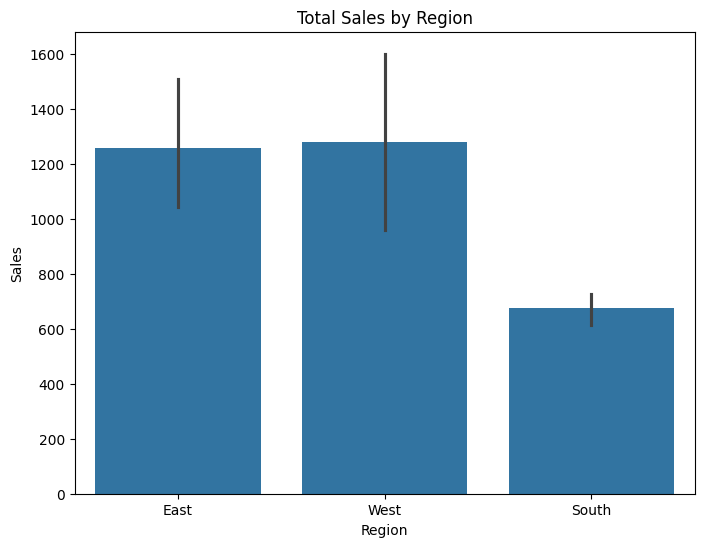

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
Region_sales = sales.groupby('Region')['Sales'].sum().reset_index()
plt.figure(figsize=(8,6))
sns.barplot(x='Region',
            y='Sales',
            data=sales)
plt.title('Total Sales by Region')
plt.show()


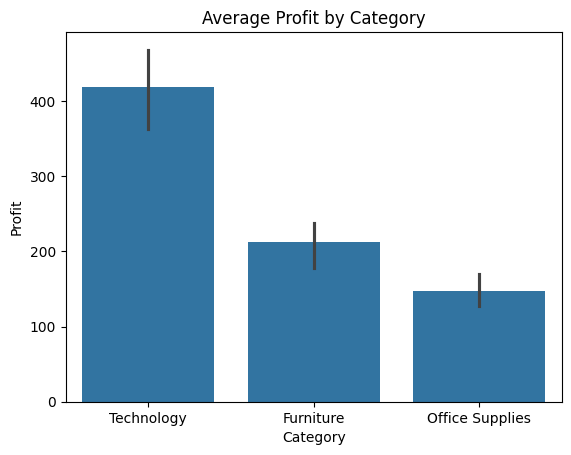

In [18]:
category_profit = sales.groupby('Category')['Profit'].sum().reset_index()
sns.barplot(x='Category',
            y='Profit',
            data=sales)
plt.title('Average Profit by Category')
plt.show()

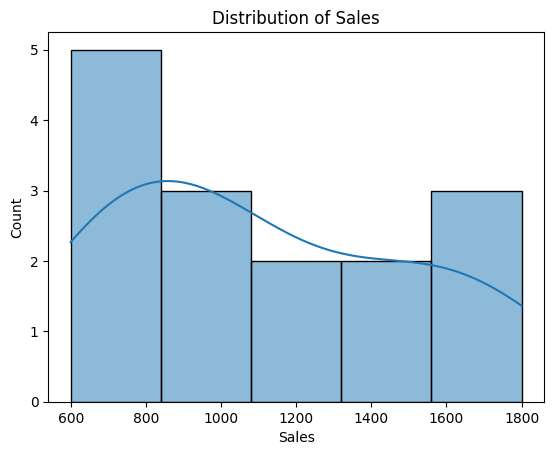

In [10]:
sns.histplot(data=sales, x='Sales', kde=True)
plt.title('Distribution of Sales')
plt.show()


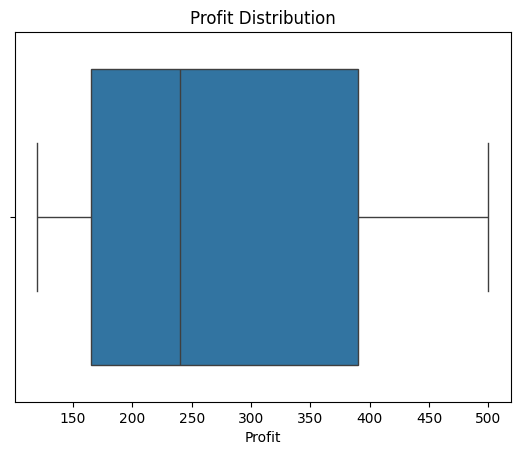

In [11]:
sns.boxplot(x='Profit', data=sales)
plt.title('Profit Distribution')
plt.show()

**Executive Summary**

***Insight 1 :***
Th company is making morre sales in East Region (7550) making it the strongest

***Insight 2***
Technology deserve more investment since it earns the company more profit

***Insight 3***
Consumer segmentis more valuable compared to the rest of segment

***Insight 4***
The company should put more investment in the technology category in the most profitabe regions which is East

In [3]:
sales.to_csv('sales.csv', index=False)

In [4]:
import os

os.listdir()

['.config', 'sales.csv', 'sample_data']

In [5]:
sales_check = pd.read_csv('sales.csv')

sales_check.head()

,OrderID,Region,Segment,Category,Sales,Profit
0,1001,East,Consumer,Technology,1200,300
1,1002,West,Corporate,Furniture,800,150
2,1003,East,Consumer,Technology,1500,400
3,1004,South,Home Office,Office Supplies,600,120
4,1005,West,Corporate,Furniture,900,200


In [6]:
sales


,OrderID,Region,Segment,Category,Sales,Profit
0,1001,East,Consumer,Technology,1200,300
1,1002,West,Corporate,Furniture,800,150
2,1003,East,Consumer,Technology,1500,400
3,1004,South,Home Office,Office Supplies,600,120
4,1005,West,Corporate,Furniture,900,200
5,1006,East,Consumer,Technology,1800,500
6,1007,South,Home Office,Office Supplies,700,150
7,1008,West,Consumer,Technology,1600,450
8,1009,East,Corporate,Furniture,1100,250
9,1010,South,Home Office,Office Supplies,750,180
